# Bài tập: Dự đoán giá nhà ở California (Regression)

**Mục tiêu**: Xây dựng mô hình Machine Learning dự đoán giá nhà dựa trên các đặc trưng được cung cấp.
**Sinh viên thực hiện**: Trần Tấn Khải .


## Bước 1: Chuẩn bị môi trường và dữ liệu


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gdown

# Cấu hình biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Tạo thư mục outputs 
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('data', exist_ok=True)


In [2]:
# Tải dữ liệu từ Google Drive
file_id = '12U_sV7KOISq_4mgZdq7gP4ANEpvu5tip'
url = f'https://drive.google.com/uc?id={file_id}'
output_path = 'data/california_housing.csv'

if not os.path.exists(output_path):
    print("Đang tải dữ liệu...")
    gdown.download(url, output_path, quiet=False)
else:
    print("Dữ liệu đã tồn tại.")

# Đọc dữ liệu
df = pd.read_csv(output_path)
display(df.head())


Đang tải dữ liệu...


Downloading...
From: https://drive.google.com/uc?id=12U_sV7KOISq_4mgZdq7gP4ANEpvu5tip
To: d:\California_Housing_Assignment\data\california_housing.csv
100%|██████████| 1.42M/1.42M [00:00<00:00, 1.83MB/s]


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Bước 1: Khám phá dữ liệu (EDA)
Phân tích thông tin cơ bản, dữ liệu thiếu và phân phối của biến mục tiêu.


In [3]:
# Thông tin chung về dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
# Thống kê mô tả
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
# Kiểm tra giá trị thiếu
print("Số lượng giá trị thiếu trong mỗi cột:")
display(df.isnull().sum())


Số lượng giá trị thiếu trong mỗi cột:


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

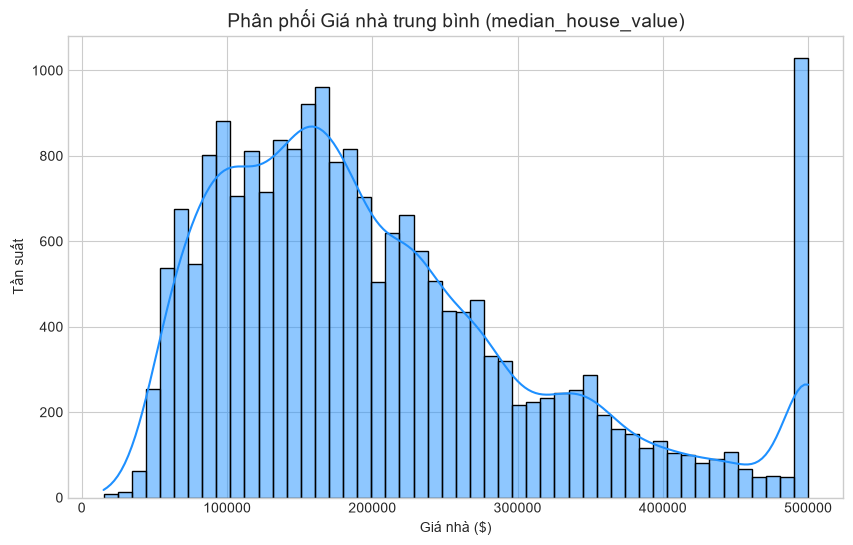

In [ ]:
# Vẽ biểu đồ phân phối của biến mục tiêu
plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], bins=50, kde=True, color='dodgerblue')
plt.title('Phân phối Giá nhà trung bình (median_house_value)', fontsize=14)
plt.xlabel('Giá nhà ($)')
plt.ylabel('Tần suất')
plt.savefig('outputs/figures/target_distribution.png', bbox_inches='tight')
plt.show()


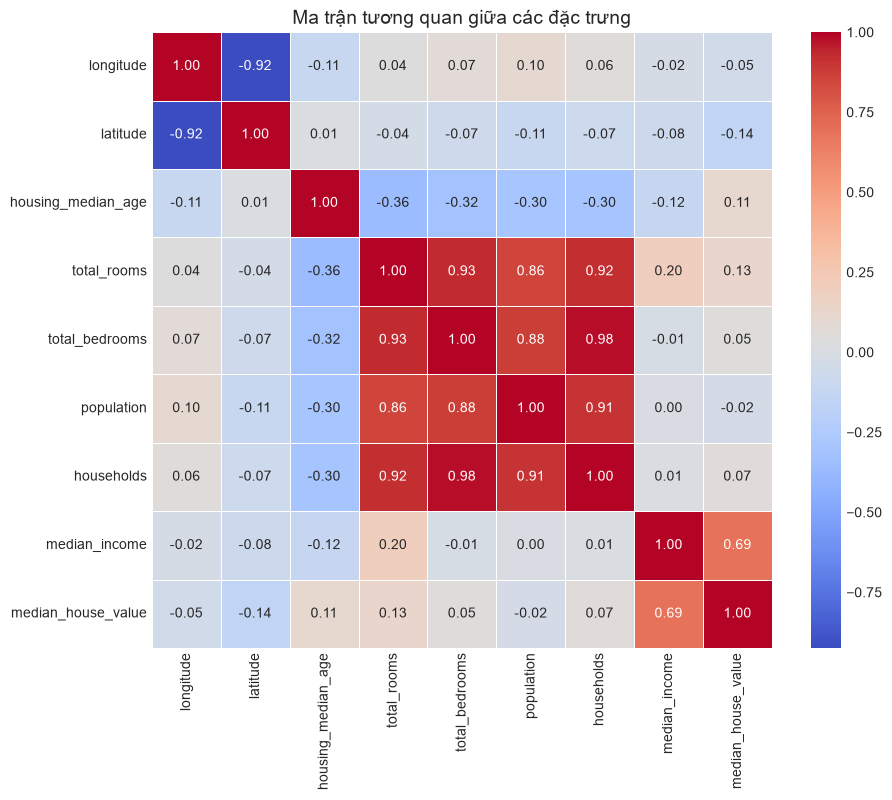

In [7]:
# Ma trận tương quan giữa các đặc trưng số học
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng', fontsize=14)
plt.savefig('outputs/figures/correlation_heatmap.png', bbox_inches='tight')
plt.show()


## Bước 2: Tiền xử lý dữ liệu
Xử lý giá trị thiếu, mã hóa biến phân loại và chuẩn hóa dữ liệu.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Xử lý giá trị phân loại: Dùng One-Hot Encoding cho cột 'ocean_proximity'
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# 2. Xử lý giá trị thiếu: Điền giá trị trung vị cho cột 'total_bedrooms'
median_bedrooms = df_encoded['total_bedrooms'].median()
df_encoded['total_bedrooms'] = df_encoded['total_bedrooms'].fillna(median_bedrooms)

print("Đã xử lý xong One-Hot Encoding và Missing values.")
display(df_encoded.head())


Đã xử lý xong One-Hot Encoding và Missing values.


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [ ]:
# Tách X  và y 
X = df_encoded.drop('median_house_value', axis=1)
y = df_encoded['median_house_value']

# Chia tập train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước tập train: {X_train.shape}")
print(f"Kích thước tập test: {X_test.shape}")


Kích thước tập train: (16512, 12)
Kích thước tập test: (4128, 12)


In [ ]:
# Chuẩn hóa dữ liệu số 
scaler = StandardScaler()

# Chỉ fit scaler trên tập train, sau đó transform cho cả train và test để tránh rò rỉ dữ liệu
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Chuyển về dạng DataFrame 
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)


## Bước 3: Huấn luyện mô hình
Sử dụng 3 mô hình: Linear Regression, Random Forest Regressor, và Support Vector Regressor (SVR).


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import time

# Khởi tạo danh sách mô hình
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "SVR": SVR(kernel='rbf')
}

trained_models = {}
training_times = {}

for name, model in models.items():
    print(f"Đang huấn luyện {name}...")
    start_time = time.time()
    
    # Huấn luyện mô hình
    model.fit(X_train_scaled, y_train)
    
    end_time = time.time()
    trained_models[name] = model
    training_times[name] = end_time - start_time
    print(f"Hoàn thành trong {training_times[name]:.2f} giây.\n")


Đang huấn luyện Linear Regression...
Hoàn thành trong 0.01 giây.

Đang huấn luyện Random Forest...
Hoàn thành trong 1.39 giây.

Đang huấn luyện SVR...
Hoàn thành trong 10.59 giây.



## Bước 4: Đánh giá mô hình
Tính toán các chỉ số MAE, MSE, RMSE, R2 Score và vẽ các biểu đồ đánh giá trực quan.


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []
predictions = {}

for name, model in trained_models.items():
    # Dự đoán trên tập test
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    # Tính các chỉ số đánh giá
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2,
        "Training Time (s)": training_times[name]
    })

# Đưa kết quả vào DataFrame để hiển thị thành bảng
results_df = pd.DataFrame(results).set_index("Model")
display(results_df)

# Lưu kết quả
results_df.to_csv('outputs/results.csv')


,MAE,MSE,RMSE,R2 Score,Training Time (s)
Model,,,,,
Linear Regression,50670.738241,4.908477e+09,70060.521845,0.625424,0.006136
Random Forest,31631.018675,2.401861e+09,49008.789216,0.816709,1.386471
SVR,86961.497845,1.365597e+10,116858.775898,-0.042115,10.585314


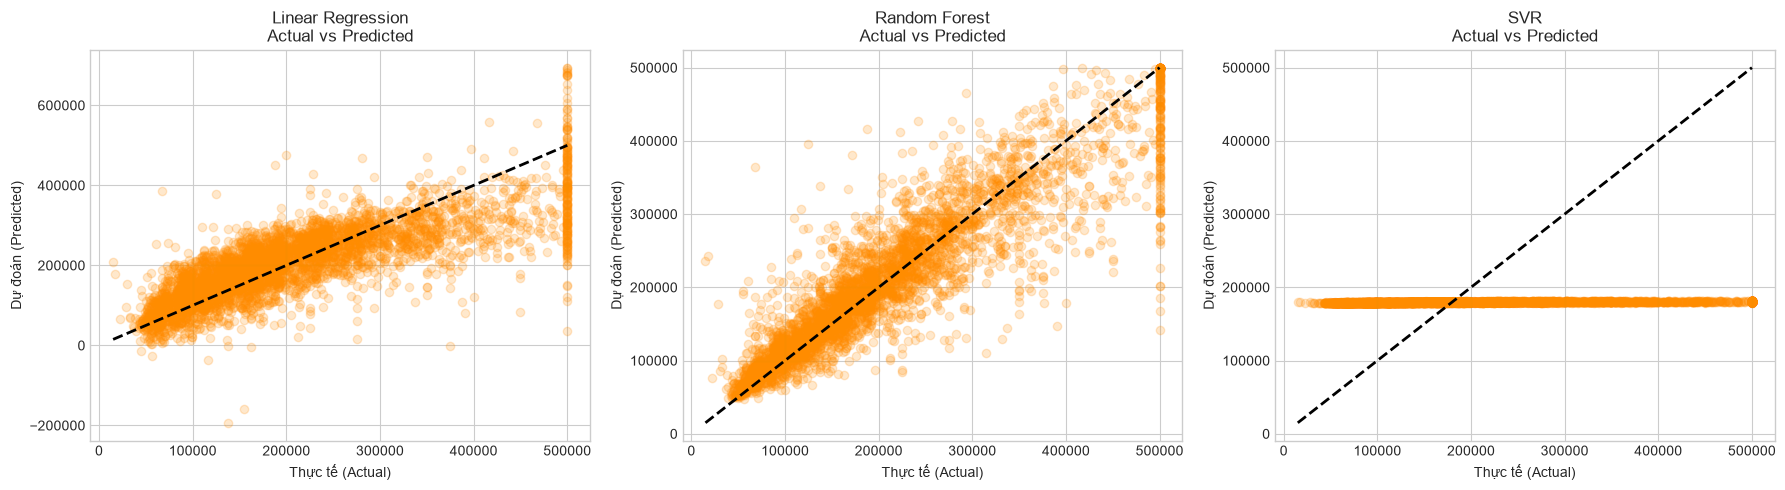

In [13]:
# Vẽ biểu đồ Actual vs Predicted cho từng mô hình
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, name in enumerate(models.keys()):
    ax = axes[idx]
    y_pred = predictions[name]
    
    # Vẽ các điểm dự đoán
    ax.scatter(y_test, y_pred, alpha=0.2, color='darkorange')
    # Vẽ đường thẳng y = x (hoàn hảo)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    ax.set_title(f'{name}\nActual vs Predicted')
    ax.set_xlabel('Thực tế (Actual)')
    ax.set_ylabel('Dự đoán (Predicted)')

plt.tight_layout()
plt.savefig('outputs/figures/actual_vs_predicted.png', bbox_inches='tight')
plt.show()


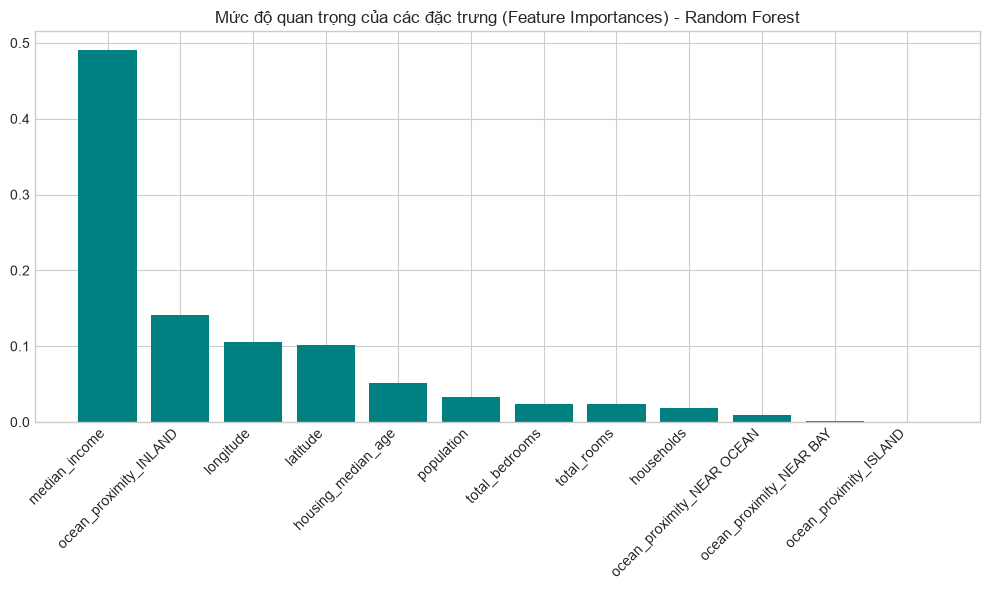

In [14]:
# Feature Importance của Random Forest
rf_model = trained_models["Random Forest"]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Mức độ quan trọng của các đặc trưng (Feature Importances) - Random Forest")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='teal')
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=45, ha='right')
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.savefig('outputs/figures/feature_importance.png')
plt.show()


## Bước 5: Phân tích và so sánh kết quả

**1. Bảng tóm tắt kết quả (Evaluation Metrics)**

| Mô hình | MAE | RMSE | R2 Score | Thời gian huấn luyện |
| :--- | :--- | :--- | :--- | :--- |
| **Linear Regression** | $50,670 | $70,060 | 0.625 | ~0.006s |
| **Random Forest** | $31,631 | $49,008 | **0.816** | ~1.38s |
| **SVR** | $86,961 | $116,858 | -0.042 | ~10.58s |

**2. Mô hình nào cho kết quả tốt nhất? Dựa trên chỉ số nào?**
- **Random Forest Regressor** là mô hình cho kết quả vượt trội nhất. 
- Dựa trên chỉ số **R2 Score** và **RMSE** để lựa chọn. R2 Score của Random Forest đạt cao nhất (khoảng **0.816**), tức là mô hình giải thích được hơn 81.6% sự biến thiên của giá nhà. Đồng thời, sai số bình phương trung bình (RMSE) của Random Forest chỉ là ~$49,008, thấp nhất trong cả 3 mô hình.

**3. Vì sao Random Forest lại hoạt động tốt hơn các mô hình còn lại?**
Dữ liệu giá nhà ở California chứa nhiều mối quan hệ phi tuyến tính phức tạp (giá nhà không tăng/giảm theo một đường thẳng tuyệt đối dựa trên vị trí địa lý hay số lượng phòng ngủ).
- Linear Regression chỉ tìm được đường thẳng cơ bản nên bị giới hạn độ chính xác.
- Trong khi đó, **Random Forest** là một thuật toán tập hợp (Ensemble) sử dụng nhiều cây quyết định, nó có khả năng phân nhánh và nắm bắt các quy luật dữ liệu phức tạp, phi tuyến tính và chống nhiễu (outliers) tốt hơn rất nhiều.

**4. Có dấu hiệu Overfitting hoặc Underfitting không?**
- **Underfitting (Khớp dưới):** Mô hình SVR với tham số mặc định đang gặp hiện tượng underfitting nghiêm trọng (R2 âm: -0.042). Mô hình Linear Regression cũng có dấu hiệu hơi underfitting vì R2 chỉ đạt mức trung bình (0.62) do mô hình quá đơn giản để "hiểu" hết dữ liệu phức tạp.
- **Overfitting (Quá khớp):** Mặc dù Random Forest cho kết quả cực kỳ tốt trên tập Test (R2 > 0.8), nhưng thuật toán dựa trên Cây Quyết Định thường rất dễ bị Overfitting. Tuy nhiên, kết quả dự đoán trên tập test vẫn đạt 0.816 cho thấy mô hình tổng quát hóa khá tốt chứ không bị quá khớp nghiêm trọng.

**5. Những khó khăn gặp phải trong quá trình thực hiện**
- Khó khăn lớn nhất là ở mô hình **SVR (Support Vector Regressor)**. Thuật toán này không chỉ chạy cực kỳ chậm mà còn cho ra kết quả dự đoán cực kỳ kém (R2 âm).
- Nguyên nhân là do SVR rất nhạy cảm với đơn vị (scale) của biến mục tiêu `y`. Mặc dù đã chuẩn hóa các biến độc lập (X), nhưng biến giá nhà (y) có khoảng cách quá lớn (lên tới 500,000 USD), khiến SVR với tham số `C=1.0` mặc định không thể tối ưu hóa được margin, dẫn đến dự đoán sai lệch hoàn toàn.

**6. Hướng cải thiện mô hình trong tương lai**
- **Với SVR:** Cần chuẩn hóa (Scale) cả biến mục tiêu `y` hoặc dùng `GridSearchCV` để tinh chỉnh siêu tham số (tăng `C`, điều chỉnh `gamma` hoặc `epsilon`) để SVR hoạt động đúng.
- **Với Random Forest:** Có thể tối ưu thêm `max_depth` hoặc `min_samples_leaf` để tránh tối đa rủi ro Overfitting.
- **Thử nghiệm mô hình mới:** Áp dụng các mô hình Tree-based mạnh mẽ hơn và huấn luyện nhanh hơn như XGBoost hoặc LightGBM.
- **Feature Engineering:** Có thể tạo thêm các đặc trưng mới từ dữ liệu gốc, ví dụ như tỷ lệ "số phòng / người" (bedrooms_per_person) để mô hình học được nhiều quy luật hay hơn.
